# L4b Advanced: First-Passage Rules Under Geometric Brownian Motion

The L4b lecture computed the probability that a scheduled long position clears a target at the exit date $T$. The L4a advanced first-passage notebook showed that a take-profit or stop-loss rule monitored before $T$ is a different, path-dependent question, and answered it on a binomial lattice by propagating only the probability mass that has not yet exited. This notebook asks the same monitored question of geometric Brownian motion. For a single barrier there is a closed form (the reflection principle); for two barriers we run the L4a absorbing recursion on the lattice calibrated to GBM and confirm it with Monte Carlo; and we quantify how much daily monitoring differs from continuous monitoring.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> - **Separate reaching from finishing:** Compute the probability that GBM reaches a take-profit level at some time before the horizon, compare it with the probability of finishing above that level, and explain why the first is larger.
> - **Evaluate two-barrier exit rules:** Use the L4a absorbing recursion on a GBM-calibrated lattice, and a Monte Carlo simulation, to find the probabilities of hitting the take-profit first, the stop-loss first, or neither by the horizon.
> - **Quantify the monitoring frequency:** Show that daily monitoring reaches a barrier less often than continuous monitoring, that the gap shrinks with the square root of the step, and that a simple barrier shift corrects for it.

Let's get started!
___

## Setup, Data, and Prerequisites

We use the constant-parameter GBM of the lecture, in log-price form, together with the GBM-calibrated binomial lattice from the companion lattice-limit notebook. The local `Include.jl` file activates the course project and loads the required packages.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file activates the course project and loads [the `DataFrames.jl` package](https://dataframes.juliadata.org/stable/) for tabular results, [the `Distributions.jl` package](https://juliastats.org/Distributions.jl/stable/) for the normal and binomial distributions, [the `Plots.jl` package](https://docs.juliaplots.org/stable/) for figures, [the `PrettyTables.jl` package](https://ronisbr.github.io/PrettyTables.jl/stable/) for tables, and the `Random` and `Statistics` standard libraries for the Monte Carlo simulation. This notebook defines its own functions, so no local source files are loaded. Let's set the plotting defaults:

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

___

## 1. Reaching a barrier versus finishing above it

Write $X_{t}=\ln(S_{t}/S_{0})$ for the log price ratio. Under GBM, $X_{t}$ is a Brownian motion with drift $\nu=\mu-\sigma^{2}/2$ (the mean growth rate $\bar g$ of the lecture) and volatility $\sigma$: $X_{t}=\nu t+\sigma W(t)$. A take-profit level $U>S_{0}$ becomes an upper barrier $b=\ln(U/S_{0})>0$ in log space, and a stop-loss level $L<S_{0}$ becomes a lower barrier $a=\ln(L/S_{0})<0$.

The lecture's terminal question is $\mathbb{P}(X_{T}\geq b)=1-\Phi\bigl((b-\nu T)/(\sigma\sqrt{T})\bigr)$. The monitored question is whether the running maximum $M_{T}=\max_{0\leq s\leq T}X_{s}$ reaches $b$ at any time before $T$. For Brownian motion with drift, the reflection principle gives a closed form:
$$
\mathbb{P}\left(M_{T}\geq b\right)=\Phi\!\left(\frac{\nu T-b}{\sigma\sqrt{T}}\right)+e^{2\nu b/\sigma^{2}}\,\Phi\!\left(\frac{-\nu T-b}{\sigma\sqrt{T}}\right).
$$
The first term is the probability of finishing above $b$. The second term is the extra probability of touching $b$ and then finishing below it: paths that a terminal rule never sees. Let's fix the parameters (a quarter-year holding period, a 10% take-profit and an 8% stop-loss) and compute both probabilities:

In [3]:
S₀ = 100.0      # initial share price (USD/share)
μ = 0.15        # arithmetic GBM drift (1/years)
σ = 0.30        # GBM volatility (1/sqrt(years))
T = 0.25        # horizon (years), about one trading quarter
U = 110.0       # take-profit level (USD/share)
L = 92.0        # stop-loss level (USD/share)
ν = μ - 0.5*σ^2 # drift of the log price, i.e., the mean growth rate ḡ (1/years)
b = log(U/S₀)   # upper barrier in log space
a = log(L/S₀)   # lower barrier in log space

@assert L < S₀ < U && σ > 0 && T > 0
(S₀ = S₀, μ = μ, σ = σ, T = T, U = U, L = L, ν = ν, b = b, a = a)

(S₀ = 100.0, μ = 0.15, σ = 0.3, T = 0.25, U = 110.0, L = 92.0, ν = 0.105, b = 0.09531017980432493, a = -0.08338160893905101)

Now let's implement the two probabilities as functions of the log barrier and compare them:

In [4]:
terminal_above(b::Real, ν::Real, σ::Real, T::Real) = 1 - cdf(Normal(), (b - ν*T)/(σ*sqrt(T))) # P(X_T ≥ b)

function reach_upper(b::Real, ν::Real, σ::Real, T::Real) # P(max_{s≤T} X_s ≥ b), reflection principle with drift
    @assert b > 0
    z = σ*sqrt(T)
    return cdf(Normal(), (ν*T - b)/z) + exp(2ν*b/σ^2)*cdf(Normal(), (-ν*T - b)/z)
end

p_finish = terminal_above(b, ν, σ, T)
p_reach = reach_upper(b, ν, σ, T)
println("Finish above U = $(U):  P(S_T ≥ U)            = $(round(p_finish, digits = 4))")
println("Reach U before T:      P(max S_t ≥ U, t ≤ T) = $(round(p_reach, digits = 4))")
println("Touched U but finished below it:              $(round(p_reach - p_finish, digits = 4))")
@assert p_reach >= p_finish

Finish above U = 110.0:  P(S_T ≥ U)            = 0.3226
Reach U before T:      P(max S_t ≥ U, t ≤ T) = 0.5835
Touched U but finished below it:              0.2609


Reaching is more likely than finishing, as it must be: every path that finishes above $U$ reached it, and some paths reach it and fall back. Let's see how the gap depends on the take-profit level by sweeping $U$ from just above $S_{0}$ to well above it:

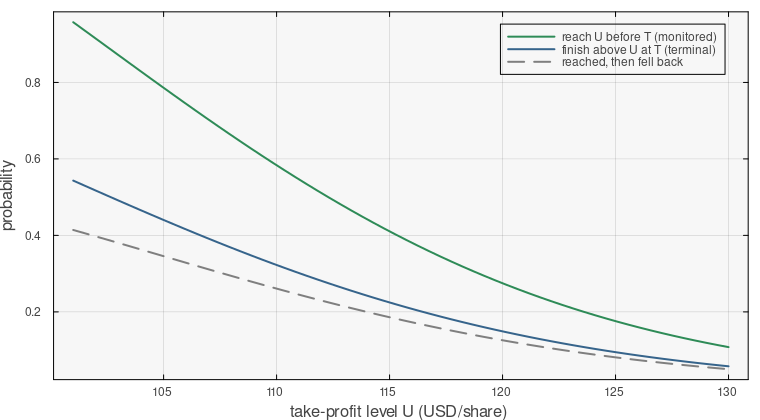

In [5]:
let
    U_grid = range(101.0, 130.0, length = 60)
    finish = [terminal_above(log(u/S₀), ν, σ, T) for u ∈ U_grid]
    reach = [reach_upper(log(u/S₀), ν, σ, T) for u ∈ U_grid]
    plot(U_grid, reach; color = :seagreen4, label = "reach U before T (monitored)",
        xlabel = "take-profit level U (USD/share)", ylabel = "probability", size = (760, 420), legend = :topright)
    plot!(U_grid, finish; color = :steelblue4, label = "finish above U at T (terminal)")
    plot!(U_grid, reach .- finish; color = :gray50, linestyle = :dash, label = "reached, then fell back")
end

For a take-profit close to the entry price almost every path touches it, while only about half finish above it; far from the entry price both probabilities are small and close together. A monitored take-profit rule and a terminal rule with the same level are different trades with different probabilities, which is the L4a lesson restated for a continuous model.

___

## 2. Two barriers: which comes first?

With both a take-profit and a stop-loss, the monitored rule exits at the first barrier reached, and the question has three answers: take-profit first, stop-loss first, or neither by $T$. There is no one-line formula for the finite-horizon two-barrier problem, so we compute it two ways. First, we run the L4a absorbing recursion, which propagates only the probability mass that has not yet exited, on the binomial lattice calibrated to GBM (up factor $e^{\sigma\sqrt{\Delta t}}$, down factor its reciprocal, up probability $\tfrac{1}{2}(1+(\nu/\sigma)\sqrt{\Delta t})$; see the lattice-limit notebook). A lattice with $N$ steps does two things at once: it quantizes the price to the nodes $S_{0}u^{k}d^{j-k}$, and it checks the barriers at every step. We want to control those separately, so we give the recursion a keyword `check_every` and test the barriers only every `check_every` steps: a fine grid with `check_every = 64` quantizes the price finely but monitors once a day, while `check_every = 1` monitors at every fine step and approximates continuous monitoring. Let's port the recursion:

In [6]:
function lattice_from_gbm(μ::Real, σ::Real, T::Real, N::Int)
    Δt = T/N
    ν = μ - 0.5*σ^2
    u = exp(σ*sqrt(Δt)); d = 1/u
    p = 0.5*(1 + (ν/σ)*sqrt(Δt))
    @assert 0 < p < 1
    return (u = u, d = d, p = p, Δt = Δt)
end

function first_passage_lattice(S₀::Real, μ::Real, σ::Real, T::Real, N::Int; lower::Real, upper::Real, check_every::Int = 1)
    @assert check_every >= 1 && N % check_every == 0 "the number of steps must be a multiple of check_every"
    lat = lattice_from_gbm(μ, σ, T, N)
    alive = [1.0]                      # open probability mass by up-count k = 0
    hit_lower = 0.0; hit_upper = 0.0
    for j ∈ 1:N
        next_alive = zeros(Float64, j + 1)
        monitor = (j % check_every == 0) # test the barriers only on monitoring dates
        for k_prev ∈ 0:(j-1)
            open_mass = alive[k_prev + 1]
            open_mass == 0.0 && continue
            for (k_new, branch_probability) ∈ ((k_prev, 1 - lat.p), (k_prev + 1, lat.p))
                mass = open_mass*branch_probability
                price = S₀*lat.u^k_new*lat.d^(j - k_new)
                if monitor && price <= lower
                    hit_lower += mass
                elseif monitor && price >= upper
                    hit_upper += mass
                else
                    next_alive[k_new + 1] += mass
                end
            end
        end
        alive = next_alive
    end
    still_open = sum(alive)
    @assert isapprox(hit_lower + hit_upper + still_open, 1.0; atol = 1e-12)
    return (take_profit_first = hit_upper, stop_loss_first = hit_lower, still_open = still_open)
end

N_fine = 63*64 # 64 grid steps per trading day over a quarter
first_passage_lattice(S₀, μ, σ, T, N_fine; lower = L, upper = U, check_every = 64) # fine price grid, daily monitoring

(take_profit_first = 0.47807398981556165, stop_loss_first = 0.4406751434126383, still_open = 0.08125086677180175)

Second, let's confirm the recursion with a Monte Carlo simulation that samples GBM paths on the same grid with the exact one-step transition of the lecture, and records which barrier each path reaches first. The simulation uses exact GBM increments, so it has no price quantization, and monitoring it once a day should agree with the finely gridded, daily-monitored recursion up to Monte Carlo error. We store the simulation in the `monte_carlo_first_passage(...)` function and run it with $N=63$ daily steps and many paths:

In [7]:
function monte_carlo_first_passage(S₀::Real, μ::Real, σ::Real, T::Real, N::Int; lower::Real, upper::Real,
        number_of_paths::Int = 100_000, seed::Int = 5660)
    rng = MersenneTwister(seed)
    Δt = T/N
    drift = (μ - 0.5*σ^2)*Δt
    shock = σ*sqrt(Δt)
    counts = Dict(:take_profit_first => 0, :stop_loss_first => 0, :still_open => 0)
    for _ ∈ 1:number_of_paths
        S = S₀
        outcome = :still_open
        for _ ∈ 1:N
            S *= exp(drift + shock*randn(rng)) # exact one-step GBM transition
            if S <= lower
                outcome = :stop_loss_first; break
            elseif S >= upper
                outcome = :take_profit_first; break
            end
        end
        counts[outcome] += 1
    end
    M = number_of_paths
    probs = (take_profit_first = counts[:take_profit_first]/M, stop_loss_first = counts[:stop_loss_first]/M, still_open = counts[:still_open]/M)
    se = map(p -> sqrt(p*(1 - p)/M), probs) # binomial standard errors
    return (probability = probs, standard_error = se)
end

mc_daily = monte_carlo_first_passage(S₀, μ, σ, T, 63; lower = L, upper = U)

(probability = (take_profit_first = 0.48394, stop_loss_first = 0.43593, still_open = 0.08013), standard_error = (take_profit_first = 0.001580322993568087, stop_loss_first = 0.0015681040625545233, still_open = 0.0008585405237960524))

Let's put the daily-monitored recursion and the daily Monte Carlo estimate side by side, and add the recursion monitored at every fine step as a stand-in for continuous monitoring, in the `two_barrier_table::DataFrame` variable. For contrast we also include the coarse 63-step lattice, which monitors daily but quantizes the price in steps of about 2%:

In [8]:
two_barrier_table = let
    lat_daily = first_passage_lattice(S₀, μ, σ, T, N_fine; lower = L, upper = U, check_every = 64) # fine grid, daily checks
    lat_cont = first_passage_lattice(S₀, μ, σ, T, N_fine; lower = L, upper = U, check_every = 1)   # fine grid, every step
    lat_coarse = first_passage_lattice(S₀, μ, σ, T, 63; lower = L, upper = U)                       # 63-step lattice
    DataFrame(
        outcome = ["Take profit first", "Stop loss first", "Still open at T"],
        lat_daily = [lat_daily.take_profit_first, lat_daily.stop_loss_first, lat_daily.still_open],
        mc_daily = [mc_daily.probability.take_profit_first, mc_daily.probability.stop_loss_first, mc_daily.probability.still_open],
        mc_se = [mc_daily.standard_error.take_profit_first, mc_daily.standard_error.stop_loss_first, mc_daily.standard_error.still_open],
        lat_cont = [lat_cont.take_profit_first, lat_cont.stop_loss_first, lat_cont.still_open],
        coarse63 = [lat_coarse.take_profit_first, lat_coarse.stop_loss_first, lat_coarse.still_open],
    )
end
pretty_table(two_barrier_table; formatters = [fmt__printf("%.4f", [2,3,4,5,6])])

┌───────────────────┬───────────┬──────────┬─────────┬──────────┬──────────┐
│           outcome │ lat_daily │ mc_daily │   mc_se │ lat_cont │ coarse63 │
│            String │   Float64 │  Float64 │ Float64 │  Float64 │  Float64 │
├───────────────────┼───────────┼──────────┼─────────┼──────────┼──────────┤
│ Take profit first │    0.4781 │   0.4839 │  0.0016 │   0.4962 │   0.4621 │
│   Stop loss first │    0.4407 │   0.4359 │  0.0016 │   0.4600 │   0.4455 │
│   Still open at T │    0.0813 │   0.0801 │  0.0009 │   0.0438 │   0.0925 │
└───────────────────┴───────────┴──────────┴─────────┴──────────┴──────────┘


The finely gridded daily recursion and the daily Monte Carlo agree to within 0.6 percentage points on every outcome. That is a few Monte Carlo standard errors, so the residual is not sampling noise: it is the 0.24% price quantization that remains on the fine grid, the same lattice error in miniature. Two correct methods for the same discretely monitored problem should agree to about this level, and they do. The recursion monitored at every fine step exits more often through both barriers and stays open less often, because a path checked more frequently is caught crossing a barrier more often; that is the monitoring effect we quantify in Section 3. The coarse 63-step lattice is off from both, because its 2% price steps move the effective barriers away from $U$ and $L$: price quantization is a separate error from monitoring frequency, and a lattice must be fine enough before it can be trusted on a barrier question. As a further check, in the limit of an infinite horizon the position must eventually exit through one barrier or the other, and the probability of the take-profit coming first has the closed form $(1-e^{-\theta a})/(e^{-\theta b}-e^{-\theta a})$ with $\theta=2\nu/\sigma^{2}$ (for $\nu\neq0$; at $\nu=0$ it reduces to $-a/(b-a)$); let's compare it with a long-horizon recursion on a fine grid:

In [9]:
let
    θ = 2ν/σ^2
    p_tp_infinite = (1 - exp(-θ*a))/(exp(-θ*b) - exp(-θ*a)) # P(hit b before a), infinite horizon, continuous monitoring
    long = first_passage_lattice(S₀, μ, σ, 3.0, 3*252*16; lower = L, upper = U) # three years, 16 checks per day
    println("Infinite-horizon closed form: P(take profit first) = $(round(p_tp_infinite, digits = 4))")
    println("Three-year fine lattice:      P(take profit first) = $(round(long.take_profit_first, digits = 4)), still open = $(round(long.still_open, digits = 6))")
    println("The residual gap combines the discrete-monitoring effect of Section 3 with the lattice node quantization; both shrink as the grid is refined.")
end

Infinite-horizon closed form: P(take profit first) = 0.5186
Three-year fine lattice:      P(take profit first) = 0.5151, still open = 0.0
The residual gap combines the discrete-monitoring effect of Section 3 with the lattice node quantization; both shrink as the grid is refined.


___

## 3. How much does the monitoring frequency matter?

A stop or take-profit checked once a day can be jumped over between checks, so a discretely monitored rule reaches a barrier less often than the continuously monitored formula predicts. Let's measure the effect for the single upper barrier of Section 1, where we have the continuous closed form. To keep price quantization out of the picture we use Monte Carlo with exact GBM increments on a fine grid of 64 steps per day, and monitor the same simulated paths at every 64th, 32nd, ..., and every step (once a day up to 64 times a day). Using the same paths for every frequency makes the differences between frequencies smooth rather than noisy. Broadie, Glasserman, and Kou showed that the discretely monitored probability is well approximated by the continuous formula with the barrier shifted away from the start by the factor $e^{\beta\sigma\sqrt{\Delta t}}$, where $\beta\approx0.5826$ and $\Delta t$ is the monitoring step; we include that corrected value too. The `gap` column is the continuous closed form minus the discretely monitored estimate, all in the `monitoring_table::DataFrame` variable:

In [10]:
function monitored_reach_frequencies(b::Real, ν::Real, σ::Real, T::Real; steps_per_day::Int = 64, days::Int = 63,
        monitor_every = (64, 32, 16, 8, 4, 2, 1), number_of_paths::Int = 100_000, seed::Int = 5660)
    N_grid = days*steps_per_day
    Δt_grid = T/N_grid
    drift = ν*Δt_grid; shock = σ*sqrt(Δt_grid)
    hits = zeros(Int, length(monitor_every))
    rng = MersenneTwister(seed)
    X = zeros(Float64, N_grid)
    for _ ∈ 1:number_of_paths
        x = 0.0
        for j ∈ 1:N_grid
            x += drift + shock*randn(rng)      # exact log-price increment on the fine grid
            X[j] = x
        end
        for (i, m) ∈ enumerate(monitor_every)  # same path, monitored at every m-th grid step
            reached = false
            for j ∈ m:m:N_grid
                if X[j] >= b
                    reached = true; break
                end
            end
            hits[i] += reached
        end
    end
    return (monitor_every = collect(monitor_every), probability = hits ./ number_of_paths, number_of_paths = number_of_paths, N_grid = N_grid)
end

monitoring_table = let
    β = 0.5826 # Broadie-Glasserman-Kou continuity correction constant
    mc = monitored_reach_frequencies(b, ν, σ, T)
    df = DataFrame(checks_per_day = Int[], Δt = Float64[], discrete = Float64[], mc_se = Float64[],
        gap = Float64[], corrected = Float64[])
    for (i, m) ∈ enumerate(mc.monitor_every)
        p_disc = mc.probability[i]
        Δt_monitor = T/(mc.N_grid ÷ m)
        corrected = reach_upper(log(U*exp(β*σ*sqrt(Δt_monitor))/S₀), ν, σ, T)
        push!(df, (64 ÷ m, Δt_monitor, p_disc, sqrt(p_disc*(1 - p_disc)/mc.number_of_paths), p_reach - p_disc, corrected))
    end
    df
end
println("Continuous-monitoring closed form: P(reach U before T) = $(round(p_reach, digits = 4))")
pretty_table(monitoring_table; formatters = [fmt__printf("%.4f", [2,3,4,5,6])])

Continuous-monitoring closed form: P(reach U before T) = 0.5835
┌────────────────┬─────────┬──────────┬─────────┬─────────┬───────────┐
│ checks_per_day │      Δt │ discrete │   mc_se │     gap │ corrected │
│          Int64 │ Float64 │  Float64 │ Float64 │ Float64 │   Float64 │
├────────────────┼─────────┼──────────┼─────────┼─────────┼───────────┤
│              1 │  0.0040 │   0.5401 │  0.0016 │  0.0434 │    0.5382 │
│              2 │  0.0020 │   0.5525 │  0.0016 │  0.0310 │    0.5513 │
│              4 │  0.0010 │   0.5616 │  0.0016 │  0.0218 │    0.5607 │
│              8 │  0.0005 │   0.5683 │  0.0016 │  0.0152 │    0.5673 │
│             16 │  0.0002 │   0.5728 │  0.0016 │  0.0107 │    0.5720 │
│             32 │  0.0001 │   0.5765 │  0.0016 │  0.0070 │    0.5754 │
│             64 │  0.0001 │   0.5786 │  0.0016 │  0.0048 │    0.5777 │
└────────────────┴─────────┴──────────┴─────────┴─────────┴───────────┘


Let's plot the gap between continuous and discrete monitoring against the step length on log axes, with a $\sqrt{\Delta t}$ reference:

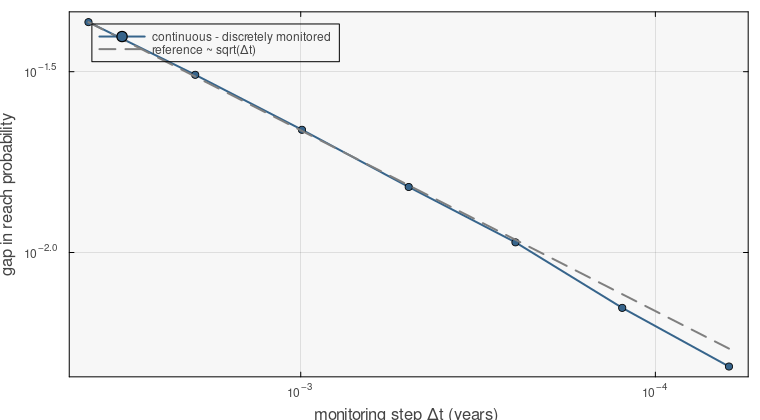

In [11]:
let
    Δt = monitoring_table.Δt
    gap = monitoring_table.gap
    plot(Δt, gap; xscale = :log10, yscale = :log10, marker = :circle, color = :steelblue4,
        label = "continuous - discretely monitored", xlabel = "monitoring step Δt (years)",
        ylabel = "gap in reach probability", size = (760, 420), legend = :topleft, xflip = true)
    plot!(Δt, gap[1] .* sqrt.(Δt ./ Δt[1]); color = :gray50, linestyle = :dash, label = "reference ~ sqrt(Δt)")
end

Daily monitoring over a quarter understates the continuous reach probability by about four percentage points, the gap shrinks like the square root of the monitoring step (each doubling of the monitoring frequency removes about 30% of it), and the shifted-barrier correction recovers the discretely monitored value to within about 0.2 percentage points at every frequency. Two practical readings follow. If a broker checks a stop once a day, the continuous formula overstates how often it fires. And if a stop is monitored continuously by the exchange, a daily simulation understates it. Either way, the monitoring convention is part of the trade rule and must be stated before a probability is quoted.

___

## Summary

This notebook carried the L4a distinction between terminal and monitored exits into the continuous-time model: reaching a barrier is more likely than finishing beyond it, two-barrier rules need the absorbing recursion or simulation, and the monitoring frequency changes the answer.

> __Key Takeaways:__
>
> - **Reflection gives the single-barrier answer:** For Brownian motion with drift, the probability of touching an upper level before the horizon is the terminal probability plus an exponentially weighted reflection term for paths that touched and fell back.
> - **Two barriers need the L4a recursion:** Propagating only the open probability mass on the GBM-calibrated lattice gives the take-profit-first, stop-loss-first, and still-open probabilities, and a Monte Carlo simulation on the same grid confirms them.
> - **Monitoring frequency is part of the rule:** Discrete monitoring reaches barriers less often than continuous monitoring, the gap shrinks with the square root of the step, and a shifted barrier corrects for it.

The next step in the course couples several GBM assets, where a portfolio-level stop-loss becomes a first-passage problem in more than one dimension.

___

## Disclaimer and Risks

This notebook is for instruction only. Barrier probabilities depend on the assumed parameters and on the stated monitoring and execution rules; a real stop or limit order need not execute at its trigger price. This material is not investment or trading advice.

___